### Save OPT-125M locally as a checkpoint

This snippet loads the pretrained OPT-125M model and tokenizer from Hugging Face, then writes a reusable local checkpoint:
- **Load artifacts**: Downloads model weights/config and tokenizer vocab/config for `facebook/opt-125m` (cached for reuse).
- **Save locally**: `model.save_pretrained('./opt125_checkpoint')` and `tokenizer.save_pretrained('./opt125_checkpoint')` create a folder with all files needed to reload offline.
- **Reload later**: You can load with `AutoModelForCausalLM.from_pretrained('./opt125_checkpoint')` and `AutoTokenizer.from_pretrained('./opt125_checkpoint')`.
- Note: This runs on CPU by default; move to GPU with `model.to('cuda')` if desired before generation (not required for saving).


In [1]:
from pathlib import Path
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# load model and tokenizer
model_name = "facebook/opt-125m"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

# save hf checkpoint under current directory (relative paths)
BASE_DIR = Path(".")
CKPT_DIR = BASE_DIR / "opt125_checkpoint"
model.save_pretrained(str(CKPT_DIR))
tokenizer.save_pretrained(str(CKPT_DIR))

print(f"Saved checkpoint to {CKPT_DIR}")

/home/rifatxia/Desktop/TensorstoreWork/tensorstore/opt-checkpointing/opt125/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved checkpoint to opt125_checkpoint


### Save weights via TensorStore (PyTorch state_dict → Tiled Zarr)

We mirror `save_pretrained` by exporting the model `state_dict()` and writing each tensor to a TensorStore-backed Zarr array. This yields a directory that can be reloaded offline without depending on Hugging Face save utilities.

- **Layout**: `./opt125_ts/weights/{param_name}` where each param is a chunked, compressed array.
- **Metadata**: We also write a minimal `config.json` alongside to mimic `save_pretrained`.
- **Reload**: Read Zarr arrays into CPU tensors and call `load_state_dict`.


In [2]:
import os, json, math
from pathlib import Path
from typing import Dict

import torch
import tensorstore as ts

BASE_DIR = Path(".")
SAVE_DIR = BASE_DIR / "opt125_ts"
WEIGHTS_DIR = SAVE_DIR / "weights"

# dirs
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

# state on cpu
state: Dict[str, torch.Tensor] = {k: v.detach().to("cpu") for k, v in model.state_dict().items()}

# simple chunk heuristic
def pick_chunks(t: torch.Tensor, target_bytes: int = 1_000_000):
    shape = list(t.shape)
    if len(shape) == 0:
        return None
    elem = t.element_size()
    chunks = shape.copy()
    while math.prod(chunks) * elem > target_bytes and chunks[-1] > 1:
        chunks[-1] = max(1, chunks[-1] // 2)
    return chunks

# write tensors
for name, tensor in state.items():
    arr_path = WEIGHTS_DIR / name
    arr_path.parent.mkdir(parents=True, exist_ok=True)

    np_arr = tensor.numpy()
    zarr_dtype = np_arr.dtype.newbyteorder('<').str

    metadata = {
        "dtype": zarr_dtype,
        "shape": list(np_arr.shape),
        "compressor": {"id": "zstd", "level": 3},
        "order": "C",
    }
    chunks = pick_chunks(tensor)
    if chunks is not None:
        metadata["chunks"] = chunks

    spec = {
        "driver": "zarr",
        "kvstore": {"driver": "file", "path": str(arr_path)},
        "metadata": metadata,
        "create": True,
        "delete_existing": True,
    }
    tstore = ts.open(spec).result()
    tstore.write(np_arr).result()

# minimal config
config = model.config.to_dict() if hasattr(model, "config") else {}
(SAVE_DIR / "config.json").write_text(json.dumps(config, indent=2))

print(f"Saved TensorStore checkpoint to {SAVE_DIR}")


Saved TensorStore checkpoint to opt125_ts


### Load model weights back from TensorStore

This reads each Zarr array under `./opt125_ts/weights`, rebuilds a PyTorch `state_dict`, instantiates a model from `config.json`, and loads the weights. You can then run generation as usual.


In [3]:
from transformers import AutoConfig

# create empty model from saved config
cfg = AutoConfig.from_pretrained("./opt125_ts")
reloaded = AutoModelForCausalLM.from_config(cfg)

# read tensors from tensorstore
reloaded_state = {}
for root, dirs, files in os.walk(WEIGHTS_DIR):
    if ".zarray" in files:
        zarr_root = root
        rel_root = os.path.relpath(zarr_root, WEIGHTS_DIR)
        spec = {"driver": "zarr", "kvstore": {"driver": "file", "path": zarr_root}}
        arr = ts.open(spec, read=True).result()
        np_arr = arr.read().result()
        key = rel_root.replace("\\", "/")
        reloaded_state[key] = torch.from_numpy(np_arr)

# load weights
missing, unexpected = reloaded.load_state_dict(reloaded_state, strict=False)
print("Missing keys:", missing)
print("Unexpected keys:", unexpected)

# quick generate and model identity check
pipe_inputs = tokenizer("Hello, my name is", return_tensors="pt")
with torch.no_grad():
    out1 = model.generate(**pipe_inputs, max_length=20)
    out2 = reloaded.generate(**pipe_inputs, max_length=20)
print("orig:", tokenizer.decode(out1[0], skip_special_tokens=True))
print("reloaded:", tokenizer.decode(out2[0], skip_special_tokens=True))

# hash of state_dict tensors to prove equality
import hashlib

def hash_state_dict(sd):
    h = hashlib.sha256()
    for k in sorted(sd.keys()):
        h.update(k.encode())
        h.update(sd[k].detach().cpu().contiguous().numpy().tobytes())
    return h.hexdigest()

orig_hash = hash_state_dict(model.state_dict())
reloaded_hash = hash_state_dict(reloaded.state_dict())
print("state_dict hash orig:", orig_hash)
print("state_dict hash reloaded:", reloaded_hash)
print("same:", orig_hash == reloaded_hash)


Missing keys: []
Unexpected keys: []
orig: Hello, my name is J.C. and I am a student at the University of California
reloaded: Hello, my name is Kaitlyn. I am a student of the English language and I
state_dict hash orig: 681529e645f341e1c148dd9f041c3884864df313f6314466377e1056cf2646ba
state_dict hash reloaded: 681529e645f341e1c148dd9f041c3884864df313f6314466377e1056cf2646ba
same: True


state_dict hash orig: 681529e645f341e1c148dd9f041c3884864df313f6314466377e1056cf2646ba
state_dict hash reloaded: 681529e645f341e1c148dd9f041c3884864df313f6314466377e1056cf2646ba
same: True


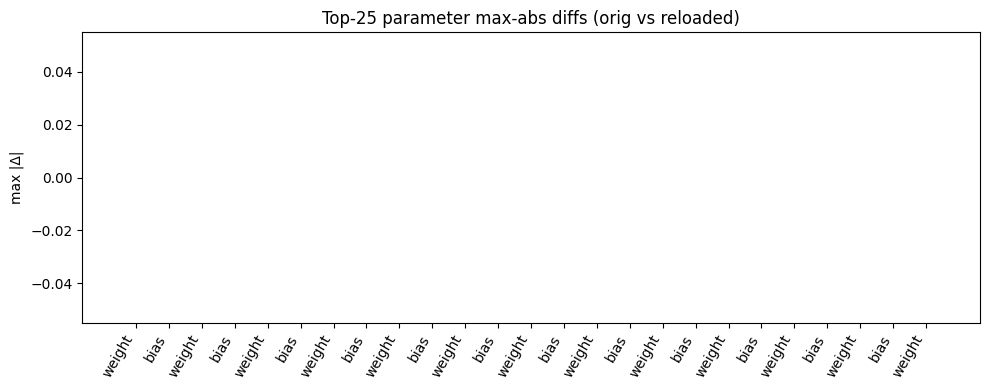

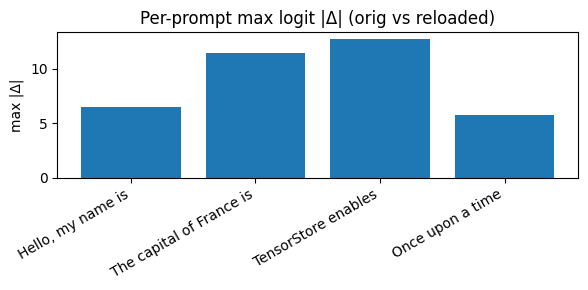

orig: Hello, my name is J.C. and I am a student at the University of California, Berkeley. I
reloaded: Hello, my name is Kari. I am a student at the University of California, Berkeley. I am a


In [4]:
# Visual verification: parameter diffs and output similarity
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

# 1) Parameter difference metrics (L2 and max-abs per parameter)
with torch.no_grad():
    sd_orig = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    sd_reload = {k: v.detach().cpu() for k, v in reloaded.state_dict().items()}

names = sorted(set(sd_orig.keys()) & set(sd_reload.keys()))
l2_diffs, max_abs_diffs = [], []
for n in names:
    a = sd_orig[n].float().contiguous()
    b = sd_reload[n].float().contiguous()
    d = (a - b)
    l2_diffs.append(float(torch.linalg.vector_norm(d)))
    max_abs_diffs.append(float(d.abs().max()))

# Plot top-25 by max-abs (should be all zeros if identical)
sorted_idx = np.argsort(max_abs_diffs)[::-1][:25]
plt.figure(figsize=(10, 4))
plt.bar(range(len(sorted_idx)), [max_abs_diffs[i] for i in sorted_idx])
plt.xticks(range(len(sorted_idx)), [names[i].split('.')[-1] for i in sorted_idx], rotation=60, ha='right')
plt.title('Top-25 parameter max-abs diffs (orig vs reloaded)')
plt.ylabel('max |Δ|')
plt.tight_layout()
plt.show()

# 2) Logit similarity over a small prompt set
prompts = [
    "Hello, my name is",
    "The capital of France is",
    "TensorStore enables",
    "Once upon a time",
]
inputs = tokenizer(prompts, return_tensors='pt', padding=True)
with torch.no_grad():
    out1 = model(**inputs)
    out2 = reloaded(**inputs)
logits1 = out1.logits.detach().cpu()
logits2 = out2.logits.detach().cpu()

# Per-prompt max absolute logit difference (across all positions and vocab)
logit_diff = (logits1 - logits2).abs()
per_prompt_max = logit_diff.max(dim=-1).values.max(dim=-1).values.numpy()

plt.figure(figsize=(6, 3))
plt.bar(range(len(prompts)), per_prompt_max)
plt.xticks(range(len(prompts)), [p[:24] + ('…' if len(p)>24 else '') for p in prompts], rotation=30, ha='right')
plt.title('Per-prompt max logit |Δ| (orig vs reloaded)')
plt.ylabel('max |Δ|')
plt.tight_layout()
plt.show()

# 3) Side-by-side sample generations for qualitative check
with torch.no_grad():
    g1 = model.generate(**tokenizer(prompts[0], return_tensors='pt'), max_length=24)
    g2 = reloaded.generate(**tokenizer(prompts[0], return_tensors='pt'), max_length=24)
print('orig:', tokenizer.decode(g1[0], skip_special_tokens=True))
print('reloaded:', tokenizer.decode(g2[0], skip_special_tokens=True))



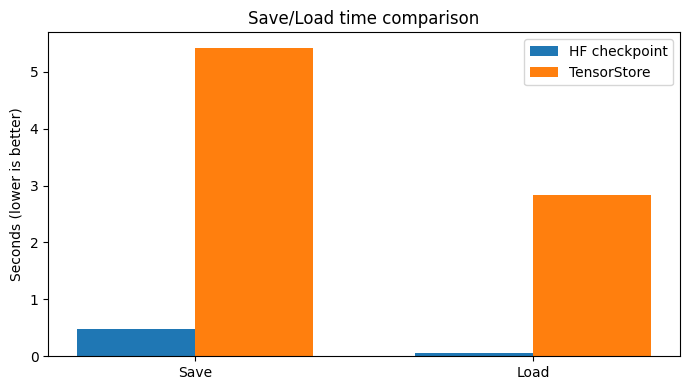

Save: TS vs HF: 5.421s vs 0.481s (-1026.5% vs HF)
Load: TS vs HF: 2.827s vs 0.062s (-4424.8% vs HF)


In [ ]:
# Timing comparison: Hugging Face checkpoint vs TensorStore export
import os, shutil, time, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
import tensorstore as ts
from transformers import AutoModelForCausalLM, AutoConfig

BASE = Path('.')
HF_DIR = BASE / 'bench_hf'
TS_DIR = BASE / 'bench_ts'
TS_WEIGHTS = TS_DIR / 'weights'

# Helpers

def rm_tree(p: Path):
    if p.exists():
        shutil.rmtree(p)

# Minimal TS save mirroring earlier cell

def ts_save_state_dict(model: torch.nn.Module, out_dir: Path):
    (out_dir / 'weights').mkdir(parents=True, exist_ok=True)
    state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
    for name, tensor in state.items():
        arr_path = out_dir / 'weights' / name
        arr_path.parent.mkdir(parents=True, exist_ok=True)
        np_arr = tensor.numpy()
        spec = {
            'driver': 'zarr',
            'kvstore': { 'driver': 'file', 'path': str(arr_path) },
            'metadata': {
                'dtype': np_arr.dtype.newbyteorder('<').str,
                'shape': list(np_arr.shape),
            },
            'create': True,
            'delete_existing': True,
        }
        store = ts.open(spec).result()
        store.write(np_arr).result()
    # config
    cfg = model.config.to_dict() if hasattr(model, 'config') else {}
    (out_dir / 'config.json').write_text(json.dumps(cfg))

# Minimal TS load mirroring earlier cell

def ts_load_state_dict(in_dir: Path) -> dict:
    weights_root = in_dir / 'weights'
    sd = {}
    for root, dirs, files in os.walk(weights_root):
        if '.zarray' in files:
            arr_root = root
            rel_key = os.path.relpath(arr_root, weights_root).replace('\\', '/')
            spec = { 'driver': 'zarr', 'kvstore': { 'driver': 'file', 'path': arr_root } }
            arr = ts.open(spec, read=True).result()
            np_arr = arr.read().result()
            sd[rel_key] = torch.from_numpy(np_arr)
    return sd

# Timers (single run each by default; set runs>1 to average)

def time_save_load(runs: int = 1):
    save_hf, save_ts, load_hf, load_ts = [], [], [], []

    for _ in range(runs):
        # Save HF
        rm_tree(HF_DIR)
        t0 = time.perf_counter()
        model.save_pretrained(str(HF_DIR))
        tokenizer.save_pretrained(str(HF_DIR))
        save_hf.append(time.perf_counter() - t0)

        # Save TS
        rm_tree(TS_DIR)
        t0 = time.perf_counter()
        ts_save_state_dict(model, TS_DIR)
        save_ts.append(time.perf_counter() - t0)

        # Load HF
        t0 = time.perf_counter()
        m_hf = AutoModelForCausalLM.from_pretrained(str(HF_DIR))
        load_hf.append(time.perf_counter() - t0)

        # Load TS
        t0 = time.perf_counter()
        cfg = AutoConfig.from_pretrained(str(TS_DIR))
        m_ts = AutoModelForCausalLM.from_config(cfg)
        sd = ts_load_state_dict(TS_DIR)
        m_ts.load_state_dict(sd, strict=False)
        load_ts.append(time.perf_counter() - t0)

    return {
        'save_hf': np.mean(save_hf),
        'save_ts': np.mean(save_ts),
        'load_hf': np.mean(load_hf),
        'load_ts': np.mean(load_ts),
    }

# Run timings
results = time_save_load(runs=1)

# Present results
labels = ['Save', 'Load']
hf_vals = [results['save_hf'], results['load_hf']]
ts_vals = [results['save_ts'], results['load_ts']]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(x - width/2, hf_vals, width, label='HF checkpoint')
plt.bar(x + width/2, ts_vals, width, label='TensorStore')
plt.xticks(x, labels)
plt.ylabel('Seconds (lower is better)')
plt.title('Save/Load time comparison')
plt.legend()
plt.tight_layout()
plt.show()

# Percent difference summary
def pct(a, b):
    return (a - b) / a * 100.0 if a > 0 else 0.0
print(f"Save: TS vs HF: {results['save_ts']:.3f}s vs {results['save_hf']:.3f}s ({pct(results['save_hf'], results['save_ts']):+.1f}% vs HF)")
print(f"Load: TS vs HF: {results['load_ts']:.3f}s vs {results['load_hf']:.3f}s ({pct(results['load_hf'], results['load_ts']):+.1f}% vs HF)")
